
Function: constant_0


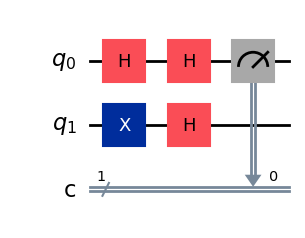

Measurement counts: {'0': 1024}
Final answer: CONSTANT

Function: constant_1


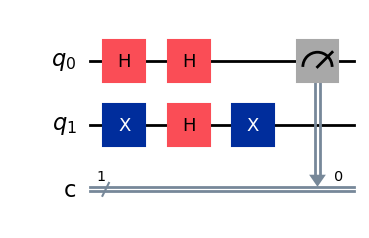

Measurement counts: {'0': 1024}
Final answer: CONSTANT

Function: balanced_x


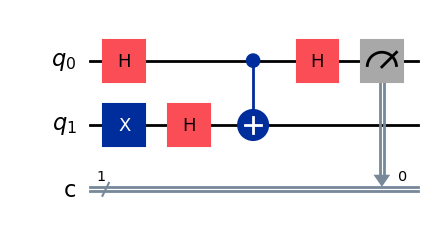

Measurement counts: {'1': 1024}
Final answer: BALANCED

Function: balanced_not_x


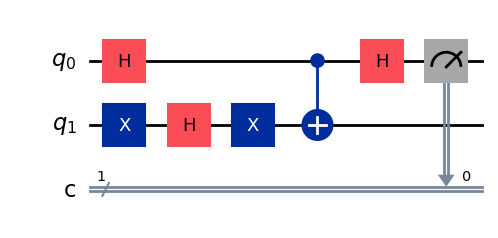

Measurement counts: {'1': 1024}
Final answer: BALANCED


In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt


# =========================================================
# GENERIC ORACLE CONSTRUCTOR
# =========================================================

def create_oracle(function_type):
    """
    Dynamically create the Deutsch oracle.

    Supported functions:
        constant_0 : f(x) = 0
        constant_1 : f(x) = 1
        balanced_x  : f(x) = x
        balanced_not_x : f(x) = 1-x
    """

    oracle = QuantumCircuit(2, name="Oracle")

    if function_type == "constant_0":
        # f(x)=0
        pass

    elif function_type == "constant_1":
        # f(x)=1
        oracle.x(1)

    elif function_type == "balanced_x":
        # f(x)=x
        oracle.cx(0, 1)

    elif function_type == "balanced_not_x":
        # f(x)=1-x
        oracle.x(1)
        oracle.cx(0, 1)

    else:
        raise ValueError(
            "Unknown function type. Use: "
            "constant_0, constant_1, balanced_x, balanced_not_x"
        )

    return oracle


# =========================================================
# DEUTSCH ALGORITHM
# =========================================================

def deutsch_algorithm(function_type, shots=1024):

    simulator = AerSimulator()

    # Create main circuit
    qc = QuantumCircuit(2, 1)

    # Prepare input qubit
    qc.h(0)

    # Prepare ancilla in |->
    qc.x(1)
    qc.h(1)

    # Create oracle
    oracle = create_oracle(function_type)

    # Add oracle to main circuit
    qc.compose(oracle, qubits=[0, 1], inplace=True)

    # Final Hadamard
    qc.h(0)

    # Measurement
    qc.measure(0, 0)

    # Display circuit
    print(f"\nFunction: {function_type}")
    print("=" * 50)

    display(qc.draw("mpl"))

    # Run
    result = simulator.run(
        qc,
        shots=shots
    ).result()

    counts = result.get_counts()

    print("Measurement counts:", counts)

    # Plot histogram
    plot_histogram(counts)
    plt.show()

    # Determine classification
    zero_count = counts.get("0", 0)
    one_count = counts.get("1", 0)

    if zero_count > one_count:
        classification = "CONSTANT"
    else:
        classification = "BALANCED"

    print("Final answer:", classification)

    return classification


# =========================================================
# TEST ALL FOUR FUNCTIONS
# =========================================================

functions = [
    "constant_0",
    "constant_1",
    "balanced_x",
    "balanced_not_x"
]

for function in functions:
    deutsch_algorithm(function)